In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

In [29]:
# generate a random unit vector
def random_unit_vector():
    vec = np.random.normal(size=3)
    return vec / np.linalg.norm(vec)

# project to xy plane
def project_to_2d(vec):
    projection_matrix = np.array([[1, 0, 0], [0, 1, 0]])
    return projection_matrix @ vec

# calculate angle between vectors
def angle_between_vectors(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    a = np.arccos(np.clip(cos_theta, -1.0, 1.0)) * (180 / np.pi)  # Convert to degrees
    if a > 90:
        return 180 - a
    else:
        return a
    
# simulate a random sample of angles
def simulate_angle_dist(n):
    angles = []
    for _ in range(n):
        v1 = project_to_2d(random_unit_vector())
        v2 = project_to_2d(random_unit_vector())
        angle = angle_between_vectors(v1, v2)
        angles.append(angle)
    return angles

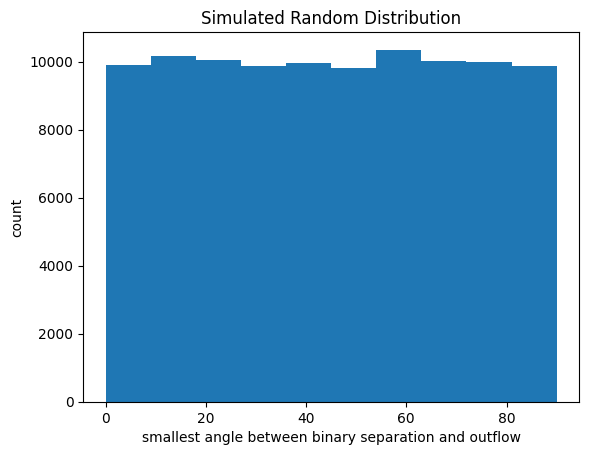

In [30]:
random_dist = simulate_angle_dist(100000)
plt.hist(random_dist)
plt.title("Simulated Random Distribution")
plt.xlabel('smallest angle between binary separation and outflow')
plt.ylabel('count')
plt.show()

According to the above histogram, generating a random outflow vector and a random separation vector and computing the smallest angle between them yields a uniform distribution as n becomes large.

**Null Hypothesis**: The measured angles are uniformly distributed

**Alternative Hypothesis**: The measured angles are not uniformly distributed

In [31]:
# load measured angles
angles = pd.read_csv('../results/angles.csv')
measured_angles = angles['smallest_angle'].to_numpy()
measured_angles_normalized = measured_angles / 90

# perform 1-sample Kolmogorov-Smirnov test
p_value = stats.kstest(measured_angles_normalized, 'uniform').pvalue
print(f"p-value : {p_value}")

p-value : 0.0017202771539026607


The one-sample Kolmogorov-Smirnov test is used to determine whether a sample came from a given reference probability distribution. The null hypothesis assumes that the sample was drawn from the reference distribution. We perform this test using our measured angles as the sample and a uniform distribution as the reference distribution. Adopting a significance level of 0.05, we reject the null hypothesis and accept the alternative hypothesis that the measured angles are not uniformly distributed. Therfore, the outflows are not randomly oriented, but are preferentially oriented.